# Titanic Passenger Survival Prediction
## Using LightGBM (Light Gradient Boosting Machine)

---

### Overview

This notebook presents a complete machine learning pipeline to predict passenger survival on the Titanic.
We will use **LightGBM (Light Gradient Boosting Machine)** — a highly efficient, distributed gradient boosting
framework developed by Microsoft that uses histogram-based learning and a leaf-wise tree growth strategy.

**Why LightGBM?**
- Faster training speed and higher efficiency compared to traditional GBDT implementations
- Lower memory usage through histogram-based binning of features
- Supports categorical features natively without extensive preprocessing
- Delivers excellent accuracy on structured / tabular datasets
- Scales easily to very large datasets with millions of rows

---

### Pipeline Overview

| Step | Description |
|------|-------------|
| 1 | Import Libraries |
| 2 | Load Dataset |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Preprocessing Pipeline |
| 6 | Model Training with LightGBM |
| 7 | Hyperparameter Tuning |
| 8 | Model Evaluation |
| 9 | Inference on New Passengers |
| 10 | Save Model Artifacts |

---
## Step 1 — Import Libraries

We begin by importing all necessary libraries for data manipulation, visualization, preprocessing, modeling,
and evaluation. Centralizing imports at the top follows Python best practices and makes dependency tracking straightforward.

In [41]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, ConfusionMatrixDisplay
)
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

plt.style.use("seaborn-v0_8-whitegrid")
COLOR_PALETTE = ["#2563EB", "#DC2626"]

print(f"LightGBM version : {lgb.__version__}")
print(f"NumPy version    : {np.__version__}")
print(f"Pandas version   : {pd.__version__}")
print("All libraries imported successfully.")

LightGBM version : 4.7.0
NumPy version    : 2.5.1
Pandas version   : 3.0.5
All libraries imported successfully.


---
## Step 2 — Load Dataset

We load the Titanic dataset from the `Dataset/` directory. We will inspect:
- The shape and first few rows
- Column data types and non-null counts
- A summary of missing values per column

In [42]:
DATASET_PATH = "../Dataset/Titanic-Dataset.csv"

df = pd.read_csv(DATASET_PATH)

print(f"Dataset Shape : {df.shape[0]} rows x {df.shape[1]} columns")
print("\n" + "=" * 60)
print("First 5 rows:")
df.head()

Dataset Shape : 891 rows x 12 columns

First 5 rows:


,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
0,"Braund, Mr. Owen Harris",male,22.0000,1,0,S,A/5 21171,7.2500,NaN,1,3,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,C,PC 17599,71.2833,C85,2,1,1
2,"Heikkinen, Miss. Laina",female,26.0000,0,0,S,STON/O2. 3101282,7.9250,NaN,3,3,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,S,113803,53.1000,C123,4,1,1
4,"Allen, Mr. William Henry",male,35.0000,0,0,S,373450,8.0500,NaN,5,3,0


In [43]:
print("Dataset Info:")
df.info()

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Name         891 non-null    str    
 1   Sex          891 non-null    str    
 2   Age          714 non-null    float64
 3   SibSp        891 non-null    int64  
 4   Parch        891 non-null    int64  
 5   Embarked     889 non-null    str    
 6   Ticket       891 non-null    str    
 7   Fare         891 non-null    float64
 8   Cabin        204 non-null    str    
 9   PassengerId  891 non-null    int64  
 10  Pclass       891 non-null    int64  
 11  Survived     891 non-null    int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [44]:
print("Descriptive Statistics:")
df.describe(include="all")

Descriptive Statistics:


,Name,Sex,Age,SibSp,Parch,Embarked,Ticket,Fare,Cabin,PassengerId,Pclass,Survived
count,891,891,714.0000,891.0000,891.0000,889,891,891.0000,204,891.0000,891.0000,891.0000
unique,891,2,NaN,NaN,NaN,3,681,NaN,147,NaN,NaN,NaN
top,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,S,347082,NaN,G6,NaN,NaN,NaN
freq,1,577,NaN,NaN,NaN,644,7,NaN,4,NaN,NaN,NaN
mean,NaN,NaN,29.6991,0.5230,0.3816,NaN,NaN,32.2042,NaN,446.0000,2.3086,0.3838
std,NaN,NaN,14.5265,1.1027,0.8061,NaN,NaN,49.6934,NaN,257.3538,0.8361,0.4866
min,NaN,NaN,0.4200,0.0000,0.0000,NaN,NaN,0.0000,NaN,1.0000,1.0000,0.0000
25%,NaN,NaN,20.1250,0.0000,0.0000,NaN,NaN,7.9104,NaN,223.5000,2.0000,0.0000
50%,NaN,NaN,28.0000,0.0000,0.0000,NaN,NaN,14.4542,NaN,446.0000,3.0000,0.0000
75%,NaN,NaN,38.0000,1.0000,0.0000,NaN,NaN,31.0000,NaN,668.5000,3.0000,1.0000


In [45]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing (%)": missing_pct
}).query("`Missing Count` > 0").sort_values("Missing (%)", ascending=False)

print("Missing Values Summary:")
print(missing_df)

Missing Values Summary:
          Missing Count  Missing (%)
Cabin               687      77.1000
Age                 177      19.8700
Embarked              2       0.2200


---
## Step 3 — Exploratory Data Analysis (EDA)

EDA helps us understand the distribution of data and the relationship between features and the target variable (`Survived`).

Key areas we explore:
1. **Target distribution** — Are the classes balanced?
2. **Survival by key features** — Gender, passenger class, age, fare, and embarkation port
3. **Correlation heatmap** — How do numerical features relate to each other?
4. **Missing data visualization**

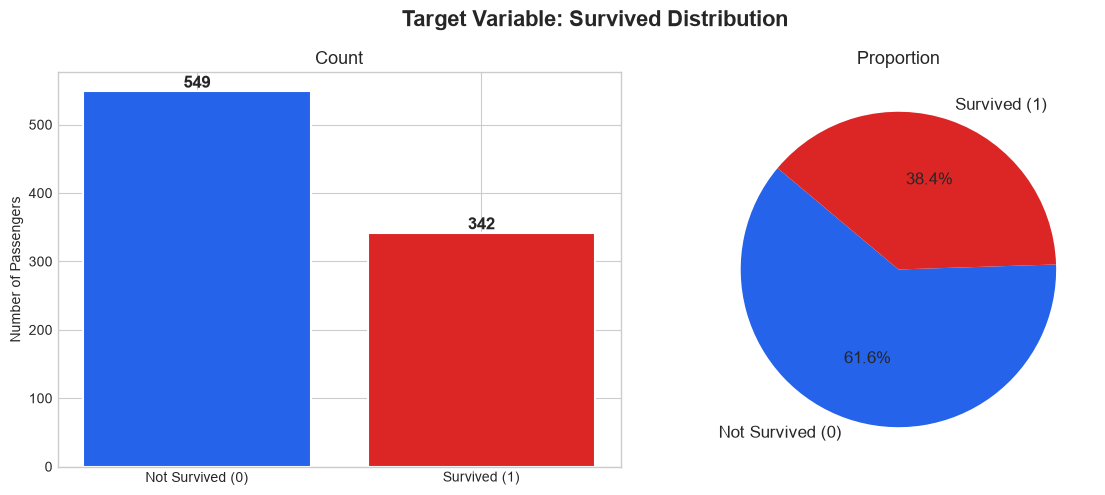

Survival Rate         : 38.38%
Class Imbalance Ratio : 1.61:1


In [46]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Target Variable: Survived Distribution", fontsize=16, fontweight="bold")

survival_counts = df["Survived"].value_counts()
labels = ["Not Survived (0)", "Survived (1)"]

axes[0].bar(labels, survival_counts.values, color=COLOR_PALETTE, edgecolor="white", linewidth=1.5)
axes[0].set_title("Count", fontsize=13)
axes[0].set_ylabel("Number of Passengers")
for i, v in enumerate(survival_counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold", fontsize=12)

axes[1].pie(
    survival_counts.values,
    labels=labels,
    colors=COLOR_PALETTE,
    autopct="%1.1f%%",
    startangle=140,
    textprops={"fontsize": 12}
)
axes[1].set_title("Proportion", fontsize=13)

plt.tight_layout()
plt.show()

survival_rate = df["Survived"].mean() * 100
ratio = survival_counts.iloc[0] / survival_counts.iloc[1]
print(f"Survival Rate         : {survival_rate:.2f}%")
print(f"Class Imbalance Ratio : {ratio:.2f}:1")

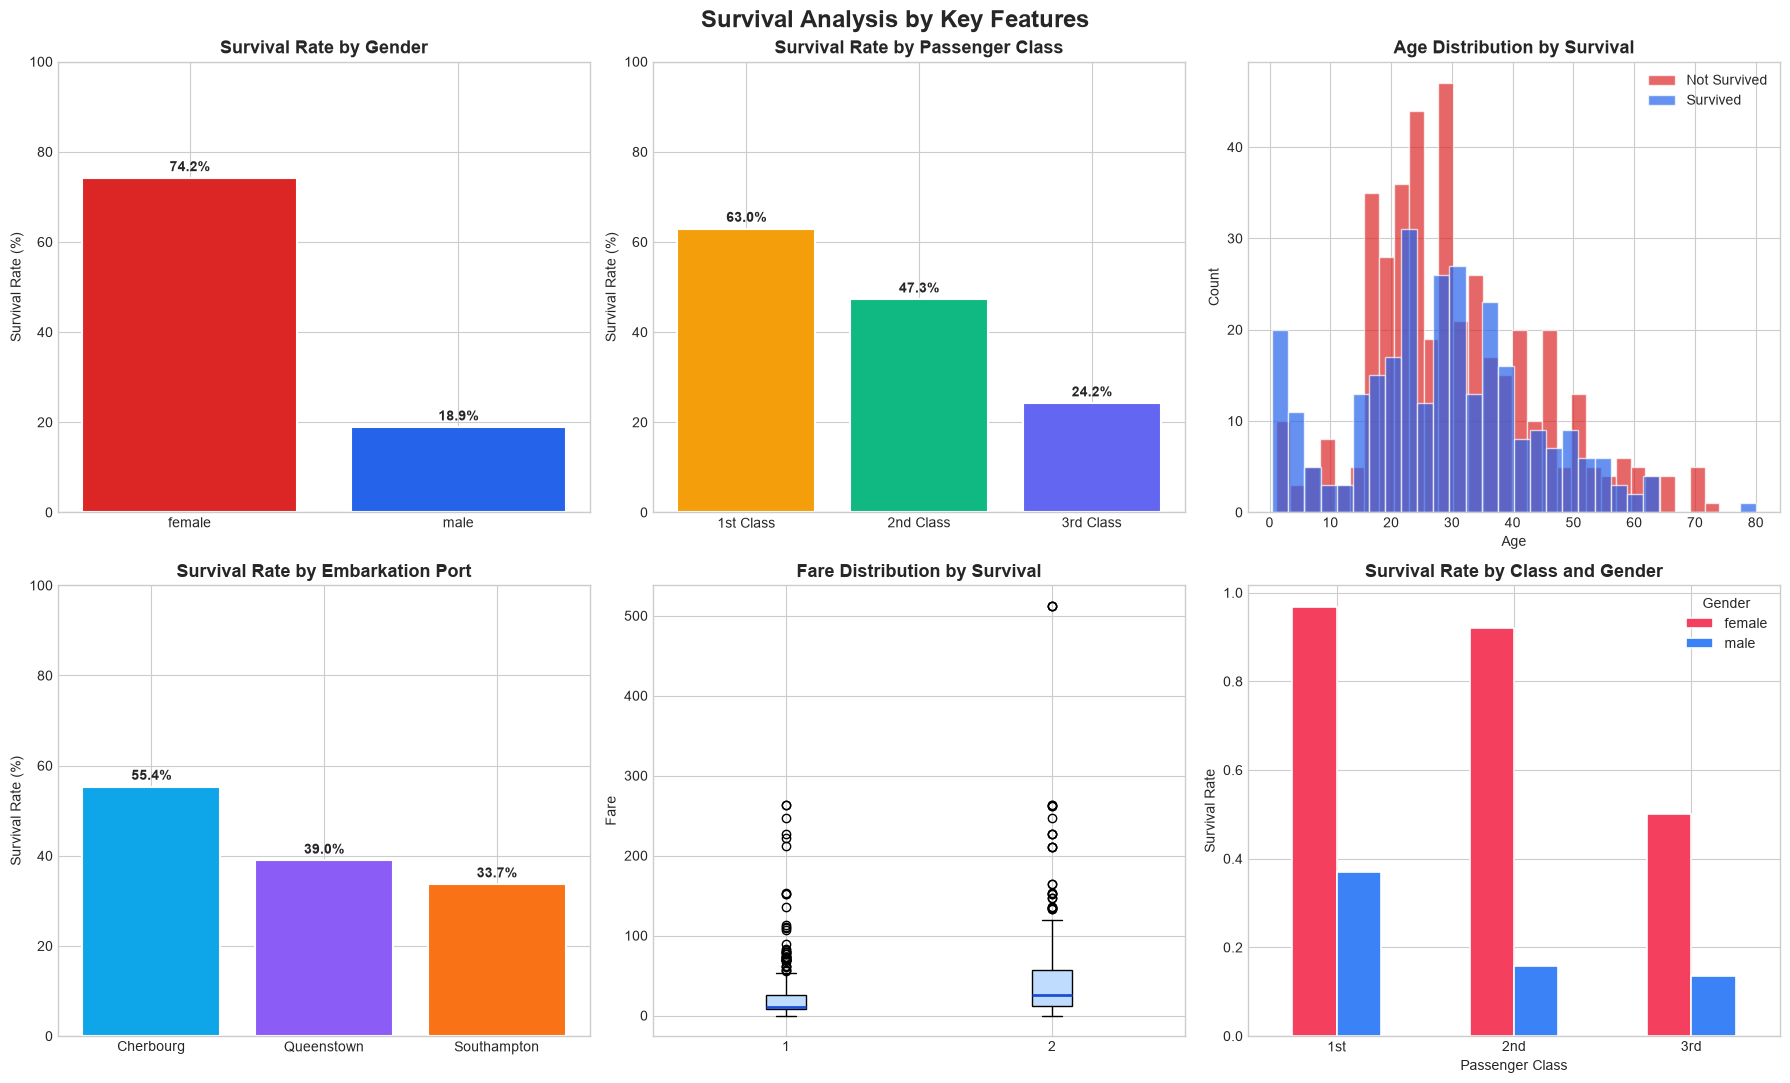

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("Survival Analysis by Key Features", fontsize=17, fontweight="bold")

survival_by_sex = df.groupby("Sex")["Survived"].mean()
axes[0, 0].bar(survival_by_sex.index, survival_by_sex.values * 100,
               color=["#DC2626", "#2563EB"], edgecolor="white", linewidth=1.5)
axes[0, 0].set_title("Survival Rate by Gender", fontsize=13, fontweight="bold")
axes[0, 0].set_ylabel("Survival Rate (%)")
axes[0, 0].set_ylim(0, 100)
for i, (idx, val) in enumerate(survival_by_sex.items()):
    axes[0, 0].text(i, val * 100 + 1.5, f"{val * 100:.1f}%", ha="center", fontweight="bold")

survival_by_class = df.groupby("Pclass")["Survived"].mean()
axes[0, 1].bar(["1st Class", "2nd Class", "3rd Class"], survival_by_class.values * 100,
               color=["#F59E0B", "#10B981", "#6366F1"], edgecolor="white", linewidth=1.5)
axes[0, 1].set_title("Survival Rate by Passenger Class", fontsize=13, fontweight="bold")
axes[0, 1].set_ylabel("Survival Rate (%)")
axes[0, 1].set_ylim(0, 100)
for i, val in enumerate(survival_by_class.values):
    axes[0, 1].text(i, val * 100 + 1.5, f"{val * 100:.1f}%", ha="center", fontweight="bold")

survived_ages = df[df["Survived"] == 1]["Age"].dropna()
not_survived_ages = df[df["Survived"] == 0]["Age"].dropna()
axes[0, 2].hist(not_survived_ages, bins=30, alpha=0.7, color="#DC2626", label="Not Survived", edgecolor="white")
axes[0, 2].hist(survived_ages, bins=30, alpha=0.7, color="#2563EB", label="Survived", edgecolor="white")
axes[0, 2].set_title("Age Distribution by Survival", fontsize=13, fontweight="bold")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Count")
axes[0, 2].legend()

survival_by_embarked = df.groupby("Embarked")["Survived"].mean()
embarked_labels = {"C": "Cherbourg", "Q": "Queenstown", "S": "Southampton"}
axes[1, 0].bar(
    [embarked_labels.get(k, k) for k in survival_by_embarked.index],
    survival_by_embarked.values * 100,
    color=["#0EA5E9", "#8B5CF6", "#F97316"], edgecolor="white", linewidth=1.5
)
axes[1, 0].set_title("Survival Rate by Embarkation Port", fontsize=13, fontweight="bold")
axes[1, 0].set_ylabel("Survival Rate (%)")
axes[1, 0].set_ylim(0, 100)
for i, val in enumerate(survival_by_embarked.values):
    axes[1, 0].text(i, val * 100 + 1.5, f"{val * 100:.1f}%", ha="center", fontweight="bold")

axes[1, 1].boxplot(
    [df[df["Survived"] == 0]["Fare"].dropna(), df[df["Survived"] == 1]["Fare"].dropna()],
    label=["Not Survived", "Survived"],
    patch_artist=True,
    boxprops=dict(facecolor="#BFDBFE"),
    medianprops=dict(color="#1D4ED8", linewidth=2)
)
axes[1, 1].set_title("Fare Distribution by Survival", fontsize=13, fontweight="bold")
axes[1, 1].set_ylabel("Fare")

pivot = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
pivot.plot(kind="bar", ax=axes[1, 2], color=["#F43F5E", "#3B82F6"], edgecolor="white", linewidth=1.2)
axes[1, 2].set_title("Survival Rate by Class and Gender", fontsize=13, fontweight="bold")
axes[1, 2].set_xlabel("Passenger Class")
axes[1, 2].set_ylabel("Survival Rate")
axes[1, 2].set_xticklabels(["1st", "2nd", "3rd"], rotation=0)
axes[1, 2].legend(title="Gender")

plt.tight_layout()
plt.show()

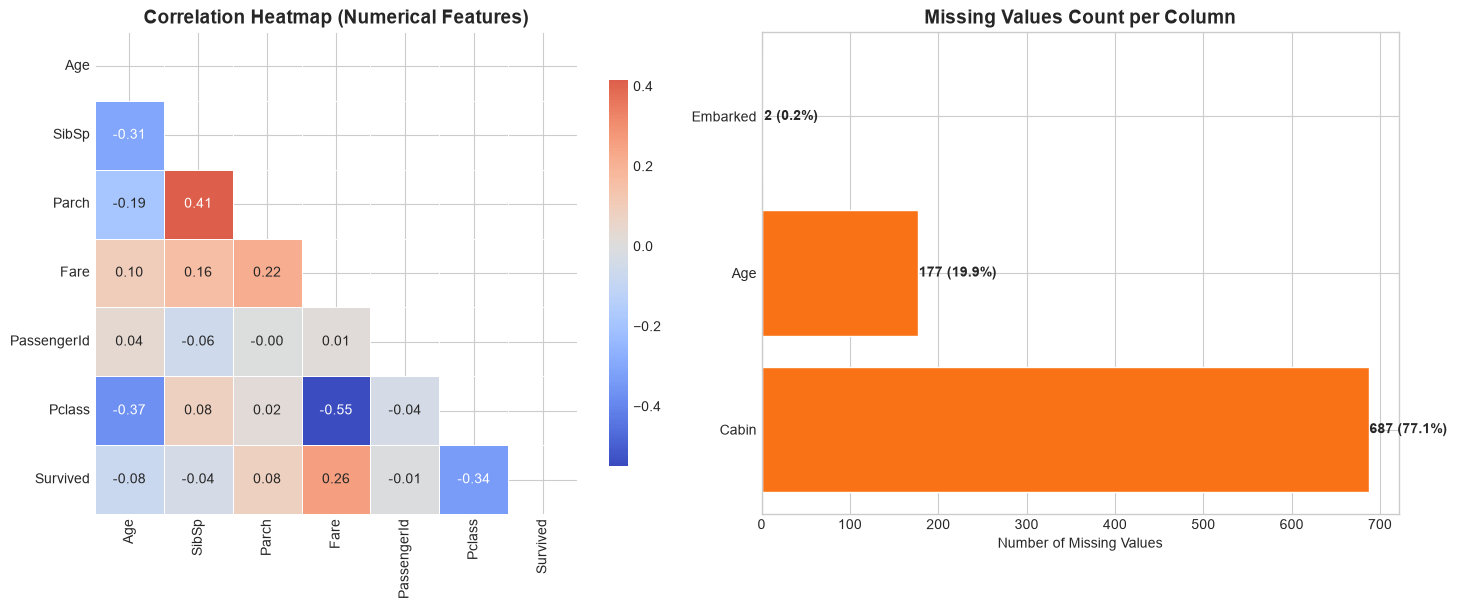

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=axes[0],
    annot=True, fmt=".2f", cmap="coolwarm",
    center=0, linewidths=0.5, square=True,
    cbar_kws={"shrink": 0.8}
)
axes[0].set_title("Correlation Heatmap (Numerical Features)", fontsize=14, fontweight="bold")

missing_data = df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)
if not missing_data.empty:
    axes[1].barh(missing_data.index, missing_data.values, color="#F97316", edgecolor="white")
    axes[1].set_title("Missing Values Count per Column", fontsize=14, fontweight="bold")
    axes[1].set_xlabel("Number of Missing Values")
    for i, v in enumerate(missing_data.values):
        axes[1].text(v + 1, i, f"{v} ({v/len(df)*100:.1f}%)", va="center", fontweight="bold")

plt.tight_layout()
plt.show()

---
## Step 4 — Feature Engineering

Raw features are often insufficient. We construct new, meaningful features derived from existing columns
to expose patterns that the model can effectively leverage:

| New Feature | Derived From | Rationale |
|---|---|---|
| `Title` | `Name` | Social title (Mr, Mrs, Miss, etc.) encodes gender, age group, and social class |
| `FamilySize` | `SibSp` + `Parch` + 1 | Total family members aboard the ship |
| `IsAlone` | `FamilySize` | Single travelers may behave differently in emergencies |
| `HasCabin` | `Cabin` | Cabin presence is a strong proxy for wealth and class |
| `CabinDeck` | `Cabin` | The deck letter extracted from the cabin number |
| `AgeBand` | `Age` | Discretized age groups to capture non-linear age effects |
| `FareBand` | `Fare` | Discretized fare groups using quartile binning |
| `FarePerPerson` | `Fare`, `FamilySize` | Fare normalized by family size |

In [49]:
def engineer_features(data):
    df_fe = data.copy()

    df_fe["Title"] = df_fe["Name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()
    rare_titles = df_fe["Title"].value_counts()[df_fe["Title"].value_counts() < 10].index
    df_fe["Title"] = df_fe["Title"].replace(rare_titles, "Rare")
    df_fe["Title"] = df_fe["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

    df_fe["FamilySize"] = df_fe["SibSp"] + df_fe["Parch"] + 1
    df_fe["IsAlone"] = (df_fe["FamilySize"] == 1).astype(int)

    df_fe["HasCabin"] = df_fe["Cabin"].notna().astype(int)
    df_fe["CabinDeck"] = df_fe["Cabin"].str[0].fillna("Unknown")

    _age_conds = [
        df_fe["Age"] <= 12,
        (df_fe["Age"] > 12) & (df_fe["Age"] <= 18),
        (df_fe["Age"] > 18) & (df_fe["Age"] <= 35),
        (df_fe["Age"] > 35) & (df_fe["Age"] <= 60),
        df_fe["Age"] > 60,
    ]
    df_fe["AgeBand"] = np.select(
        _age_conds,
        ["Child", "Teenager", "Young Adult", "Adult", "Senior"],
        default="Unknown"
    )

    _fare_conds = [
        df_fe["Fare"] <= 7.91,
        (df_fe["Fare"] > 7.91) & (df_fe["Fare"] <= 14.454),
        (df_fe["Fare"] > 14.454) & (df_fe["Fare"] <= 31.0),
        df_fe["Fare"] > 31.0,
    ]
    df_fe["FareBand"] = np.select(
        _fare_conds,
        ["Low", "Medium", "High", "Very High"],
        default="Low"
    )

    df_fe["FarePerPerson"] = df_fe["Fare"] / df_fe["FamilySize"]

    return df_fe


df_fe = engineer_features(df)

new_features = ["Title", "FamilySize", "IsAlone", "HasCabin", "CabinDeck",
                "AgeBand", "FareBand", "FarePerPerson"]

print("Engineered Features Preview:")
df_fe[new_features].head(10)

Engineered Features Preview:


,Title,FamilySize,IsAlone,HasCabin,CabinDeck,AgeBand,FareBand,FarePerPerson
0,Mr,2,0,0,Unknown,Young Adult,Low,3.6250
1,Mrs,2,0,1,C,Adult,Very High,35.6416
2,Miss,1,1,0,Unknown,Young Adult,Medium,7.9250
3,Mrs,2,0,1,C,Young Adult,Very High,26.5500
4,Mr,1,1,0,Unknown,Young Adult,Medium,8.0500
5,Mr,1,1,0,Unknown,Unknown,Medium,8.4583
6,Mr,1,1,1,E,Adult,Very High,51.8625
7,Master,5,0,0,Unknown,Child,High,4.2150
8,Mrs,3,0,0,Unknown,Young Adult,Medium,3.7111
9,Mrs,2,0,0,Unknown,Teenager,High,15.0354


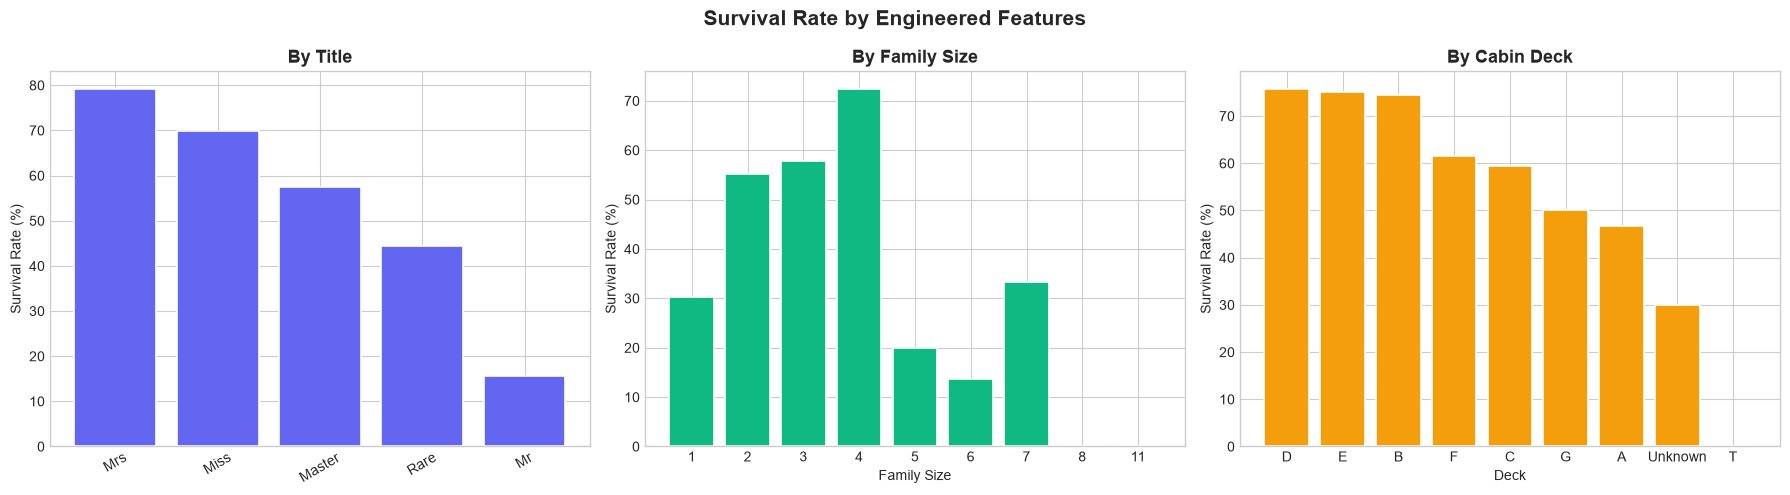

In [50]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Survival Rate by Engineered Features", fontsize=15, fontweight="bold")

survival_by_title = df_fe.groupby("Title")["Survived"].mean().sort_values(ascending=False)
axes[0].bar(survival_by_title.index, survival_by_title.values * 100,
            color="#6366F1", edgecolor="white", linewidth=1.2)
axes[0].set_title("By Title", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Survival Rate (%)")
axes[0].tick_params(axis="x", rotation=30)

survival_by_family = df_fe.groupby("FamilySize")["Survived"].mean()
axes[1].bar(survival_by_family.index.astype(str), survival_by_family.values * 100,
            color="#10B981", edgecolor="white", linewidth=1.2)
axes[1].set_title("By Family Size", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Family Size")
axes[1].set_ylabel("Survival Rate (%)")

survival_by_deck = df_fe.groupby("CabinDeck")["Survived"].mean().sort_values(ascending=False)
axes[2].bar(survival_by_deck.index, survival_by_deck.values * 100,
            color="#F59E0B", edgecolor="white", linewidth=1.2)
axes[2].set_title("By Cabin Deck", fontsize=13, fontweight="bold")
axes[2].set_xlabel("Deck")
axes[2].set_ylabel("Survival Rate (%)")

plt.tight_layout()
plt.show()

---
## Step 5 — Preprocessing Pipeline

We define a **scikit-learn Pipeline** to systematically handle all preprocessing steps. Using a pipeline guarantees:
- No data leakage between the training and test sets
- Fully reproducible transformations
- The pipeline can be serialized and reused identically at inference time

**Strategy:**
- **Numerical features** → Median imputation → StandardScaler
- **Categorical features** → Most-frequent imputation → OneHotEncoder
- **Dropped columns** → `Name`, `Ticket`, `Cabin`, `PassengerId` (high cardinality or non-informative)

In [51]:
DROP_COLS = ["Name", "Ticket", "Cabin", "PassengerId"]
TARGET    = "Survived"

df_model = df_fe.drop(columns=DROP_COLS)

X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f"Training Set   : {X_train.shape[0]} samples")
print(f"Test Set       : {X_test.shape[0]} samples")
print(f"Total Features : {X_train.shape[1]}")

Training Set   : 712 samples
Test Set       : 179 samples
Total Features : 15


In [52]:
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"Numerical Features  ({len(num_features)}) : {num_features}")
print(f"Categorical Features ({len(cat_features)}) : {cat_features}")

Numerical Features  (9) : ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass', 'FamilySize', 'IsAlone', 'HasCabin', 'FarePerPerson']
Categorical Features (6) : ['Sex', 'Embarked', 'Title', 'CabinDeck', 'AgeBand', 'FareBand']


In [53]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

print("Preprocessing pipeline built successfully.")
print(preprocessor)

Preprocessing pipeline built successfully.
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare', 'Pclass',
                                  'FamilySize', 'IsAlone', 'HasCabin',
                                  'FarePerPerson']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'Embarked', 'Tit

---
## Step 6 — Model Training with LightGBM

### About LightGBM

**LightGBM** is an ensemble method built on gradient boosted decision trees (GBDT). Unlike traditional
GBDT implementations that grow trees level-wise, LightGBM grows trees **leaf-wise** — it always selects
the leaf with the maximum delta loss to expand. This leads to:
- Faster convergence requiring fewer iterations
- Lower loss and higher accuracy on structured datasets
- Potential overfitting on very small datasets (mitigated via `min_child_samples` and regularization)

**Key Hyperparameters:**

| Parameter | Description |
|---|---|
| `n_estimators` | Number of boosting rounds |
| `learning_rate` | Shrinkage applied to each tree contribution |
| `num_leaves` | Max leaves per tree (primary complexity control in leaf-wise growth) |
| `max_depth` | Maximum tree depth (secondary guard against overfitting) |
| `min_child_samples` | Minimum samples required in a leaf node |
| `subsample` | Fraction of training data sampled per iteration |
| `colsample_bytree` | Fraction of features randomly sampled per tree |
| `reg_alpha` | L1 regularization strength |
| `reg_lambda` | L2 regularization strength |

In [54]:
lgbm_base = lgb.LGBMClassifier(
    objective="binary",
    metric="binary_logloss",
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=RANDOM_STATE,
    verbose=-1
)

full_pipeline_base = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   lgbm_base)
])

full_pipeline_base.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(full_pipeline_base, X_train, y_train,
                            cv=cv, scoring="accuracy", n_jobs=-1)

print("Base LightGBM 5-Fold CV Accuracy:")
print(f"  Scores  : {[round(s, 4) for s in cv_scores]}")
print(f"  Mean    : {cv_scores.mean():.4f}")
print(f"  Std Dev : {cv_scores.std():.4f}")

Base LightGBM 5-Fold CV Accuracy:
  Scores  : [np.float64(0.8322), np.float64(0.7832), np.float64(0.8451), np.float64(0.8451), np.float64(0.838)]
  Mean    : 0.8287
  Std Dev : 0.0233


---
## Step 7 — Hyperparameter Tuning

We use **Randomized Search Cross-Validation** to efficiently explore a broad hyperparameter space
without the prohibitive cost of an exhaustive grid search.

**Search Strategy:**
- 5-Fold Stratified Cross-Validation preserves class distribution in every fold
- 50 random hyperparameter combinations are sampled
- Optimization metric: **ROC-AUC** (robust for binary classification tasks)

In [55]:
param_distributions = {
    "classifier__n_estimators":      randint(100, 800),
    "classifier__learning_rate":     uniform(0.01, 0.2),
    "classifier__num_leaves":        randint(20, 100),
    "classifier__max_depth":         randint(3, 12),
    "classifier__min_child_samples": randint(5, 50),
    "classifier__subsample":         uniform(0.6, 0.4),
    "classifier__colsample_bytree":  uniform(0.6, 0.4),
    "classifier__reg_alpha":         uniform(0.0, 1.0),
    "classifier__reg_lambda":        uniform(0.0, 1.0),
}

lgbm_tunable = lgb.LGBMClassifier(
    objective="binary",
    random_state=RANDOM_STATE,
    verbose=-1
)

tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier",   lgbm_tunable)
])

random_search = RandomizedSearchCV(
    estimator=tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=50,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

random_search.fit(X_train, y_train)

print("\n" + "=" * 60)
print("Best Hyperparameters Found:")
for k, v in random_search.best_params_.items():
    print(f"  {k:<40} : {v}")
print(f"\nBest CV ROC-AUC : {random_search.best_score_:.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Hyperparameters Found:
  classifier__colsample_bytree             : 0.7483273008793065
  classifier__learning_rate                : 0.14376825053272146
  classifier__max_depth                    : 7
  classifier__min_child_samples            : 39
  classifier__n_estimators                 : 783
  classifier__num_leaves                   : 54
  classifier__reg_alpha                    : 0.4722149251619493
  classifier__reg_lambda                   : 0.1195942459383017
  classifier__subsample                    : 0.885297914889198

Best CV ROC-AUC : 0.8948


In [56]:
best_model = random_search.best_estimator_

cv_scores_tuned = cross_val_score(best_model, X_train, y_train,
                                  cv=cv, scoring="accuracy", n_jobs=-1)

print("Tuned LightGBM 5-Fold CV Accuracy:")
print(f"  Scores  : {[round(s, 4) for s in cv_scores_tuned]}")
print(f"  Mean    : {cv_scores_tuned.mean():.4f}")
print(f"  Std Dev : {cv_scores_tuned.std():.4f}")
print(f"\nImprovement vs Base : +{(cv_scores_tuned.mean() - cv_scores.mean()) * 100:.2f}%")

Tuned LightGBM 5-Fold CV Accuracy:
  Scores  : [np.float64(0.8322), np.float64(0.8182), np.float64(0.831), np.float64(0.831), np.float64(0.8451)]
  Mean    : 0.8315
  Std Dev : 0.0085

Improvement vs Base : +0.28%


---
## Step 8 — Model Evaluation

We evaluate the final tuned model on the **held-out test set** that was never seen during training or tuning.
This gives an unbiased estimate of real-world generalization performance.

**Metrics used:**

| Metric | Description |
|---|---|
| **Accuracy** | Overall fraction of correct predictions |
| **Precision** | Of all passengers predicted as survivors, how many truly survived? |
| **Recall** | Of all actual survivors, how many did the model correctly identify? |
| **F1-Score** | Harmonic mean of Precision and Recall |
| **ROC-AUC** | Area Under the ROC Curve — measures the model's discriminative ability |
| **Confusion Matrix** | Detailed breakdown of TP, TN, FP, FN |

In [57]:
y_pred       = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy":  accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall":    recall_score(y_test, y_pred),
    "F1-Score":  f1_score(y_test, y_pred),
    "ROC-AUC":   roc_auc_score(y_test, y_pred_proba),
}

print("=" * 50)
print("     FINAL MODEL EVALUATION — TEST SET")
print("=" * 50)
for name, value in metrics.items():
    bar = chr(9608) * int(value * 20)
    print(f"  {name:<12}: {value:.4f}  {bar}")
print("=" * 50)

print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=["Not Survived", "Survived"]))

     FINAL MODEL EVALUATION — TEST SET
  Accuracy    : 0.8212  ████████████████
  Precision   : 0.7846  ███████████████
  Recall      : 0.7391  ██████████████
  F1-Score    : 0.7612  ███████████████
  ROC-AUC     : 0.8399  ████████████████

Detailed Classification Report:
              precision    recall  f1-score   support

Not Survived       0.84      0.87      0.86       110
    Survived       0.78      0.74      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



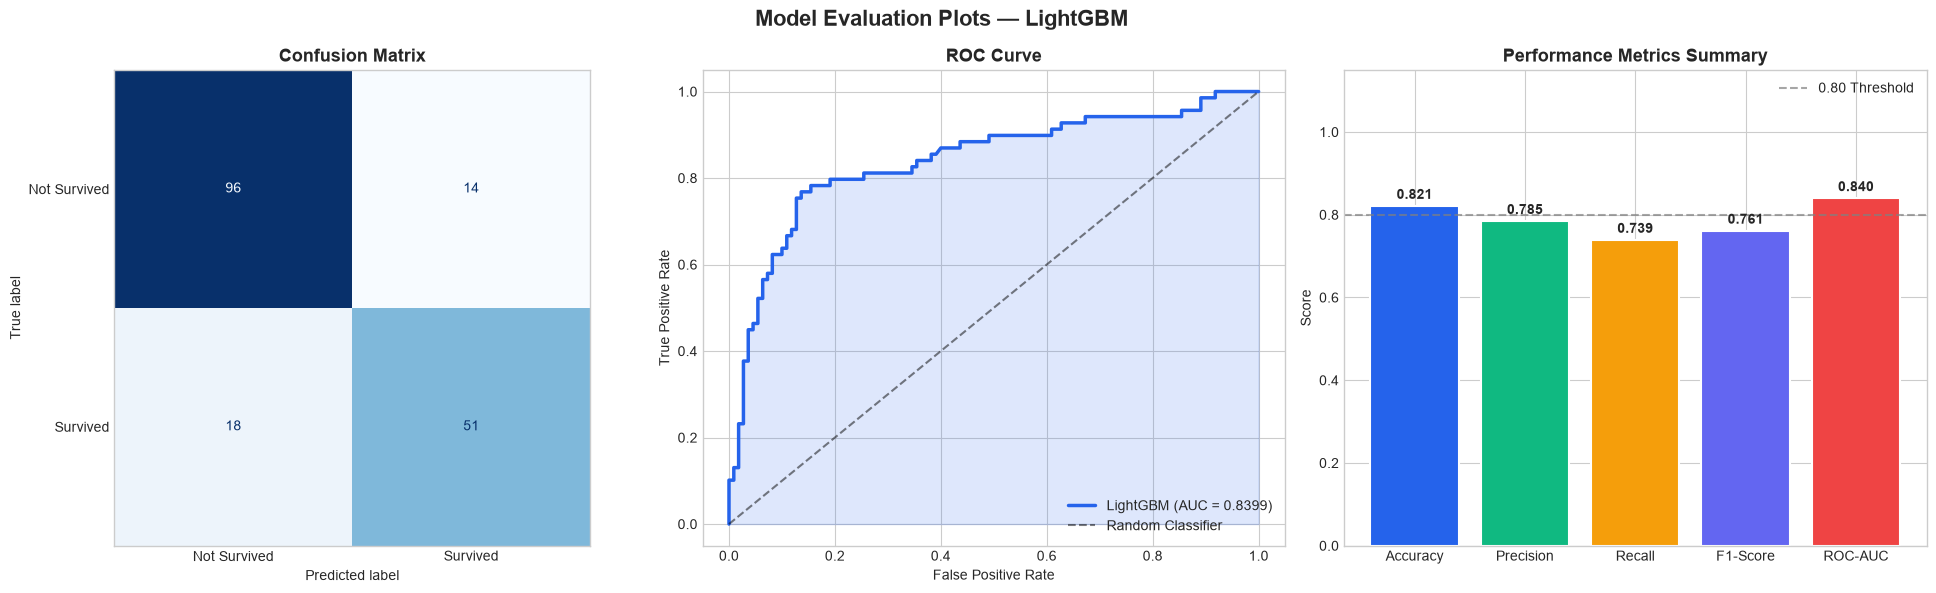

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle("Model Evaluation Plots — LightGBM", fontsize=16, fontweight="bold")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Survived", "Survived"])
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].grid(False)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color="#2563EB", lw=2.5, label=f"LightGBM (AUC = {auc_score:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.5, label="Random Classifier")
axes[1].fill_between(fpr, tpr, alpha=0.15, color="#2563EB")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve", fontsize=13, fontweight="bold")
axes[1].legend(loc="lower right")

metric_names  = list(metrics.keys())
metric_values = list(metrics.values())
bar_colors = ["#2563EB", "#10B981", "#F59E0B", "#6366F1", "#EF4444"]
bars = axes[2].bar(metric_names, metric_values, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[2].set_ylim(0, 1.15)
axes[2].set_title("Performance Metrics Summary", fontsize=13, fontweight="bold")
axes[2].set_ylabel("Score")
axes[2].axhline(y=0.8, color="gray", linestyle="--", alpha=0.7, label="0.80 Threshold")
axes[2].legend()
for bar, val in zip(bars, metric_values):
    axes[2].text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 0.01,
                 f"{val:.3f}", ha="center", va="bottom", fontweight="bold", fontsize=10)

plt.tight_layout()
plt.show()

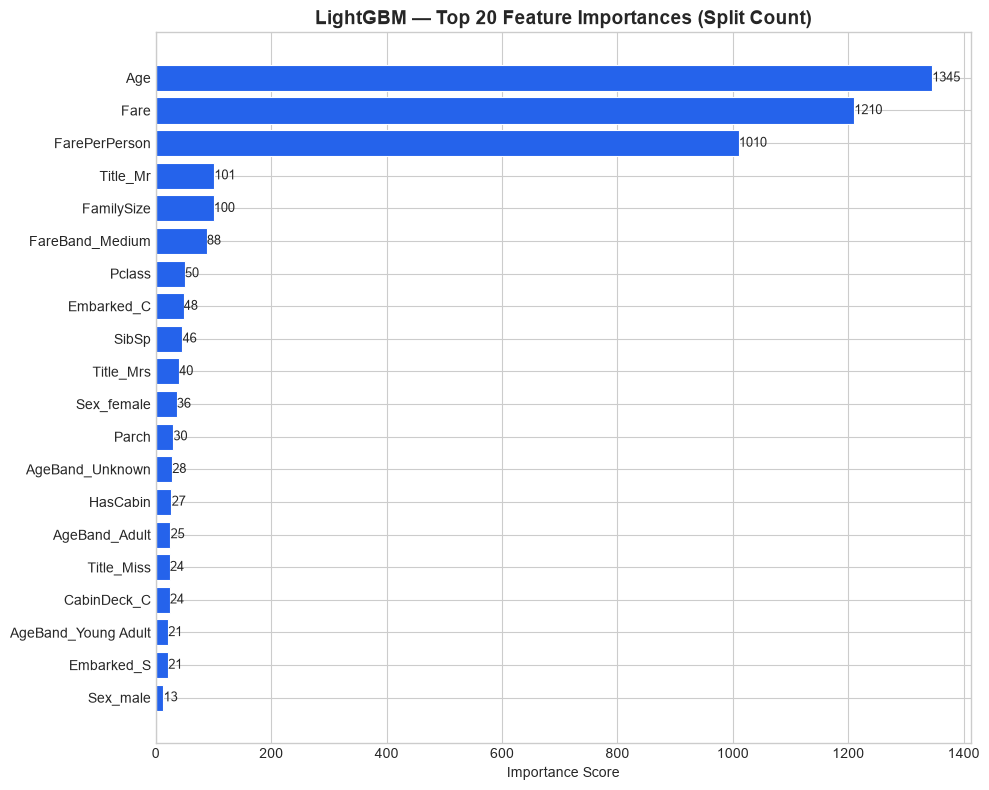

In [59]:
lgbm_classifier     = best_model.named_steps["classifier"]
preprocessor_fitted = best_model.named_steps["preprocessor"]

ohe_feature_names = (
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_features)
    .tolist()
)
all_feature_names = num_features + ohe_feature_names

importance_df = pd.DataFrame({
    "Feature":    all_feature_names,
    "Importance": lgbm_classifier.feature_importances_
}).sort_values("Importance", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(importance_df["Feature"], importance_df["Importance"],
               color="#2563EB", edgecolor="white", linewidth=0.8)
ax.set_title("LightGBM — Top 20 Feature Importances (Split Count)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Importance Score")
for bar, val in zip(bars, importance_df["Importance"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2.,
            str(int(val)), va="center", fontsize=9)
plt.tight_layout()
plt.show()

---
## Step 9 — Inference on New Passengers

We demonstrate how to use the trained pipeline to make predictions on **new, unseen passenger data**.
The inference workflow applies the same feature engineering steps automatically, then passes the result
through the full preprocessing pipeline before obtaining a prediction.

This approach ensures that raw input data is handled exactly as it was during training — a critical
requirement for reliable production deployment.

In [60]:
def prepare_inference_input(raw_input):
    df_raw = pd.DataFrame([raw_input])
    df_raw = engineer_features(df_raw)
    df_raw = df_raw.drop(columns=[c for c in DROP_COLS if c in df_raw.columns], errors="ignore")
    return df_raw


new_passengers = [
    {
        "Name": "Doe, Mr. John",
        "Sex": "male", "Age": 28.0, "SibSp": 0, "Parch": 0,
        "Embarked": "S", "Ticket": "A12345", "Fare": 8.05,
        "Cabin": None, "PassengerId": 9001, "Pclass": 3
    },
    {
        "Name": "Smith, Mrs. Margaret (Anna)",
        "Sex": "female", "Age": 35.0, "SibSp": 1, "Parch": 2,
        "Embarked": "C", "Ticket": "PC 17609", "Fare": 71.28,
        "Cabin": "C85", "PassengerId": 9002, "Pclass": 1
    },
    {
        "Name": "Brown, Miss. Emily Louise",
        "Sex": "female", "Age": 8.0, "SibSp": 2, "Parch": 1,
        "Embarked": "Q", "Ticket": "Q88888", "Fare": 21.075,
        "Cabin": None, "PassengerId": 9003, "Pclass": 3
    }
]

inference_results = []
for passenger in new_passengers:
    X_inf      = prepare_inference_input(passenger)
    pred       = best_model.predict(X_inf)[0]
    pred_proba = best_model.predict_proba(X_inf)[0]
    inference_results.append({
        "Name":              passenger["Name"],
        "Sex":               passenger["Sex"],
        "Age":               passenger["Age"],
        "Pclass":            passenger["Pclass"],
        "Prediction":        "Survived" if pred == 1 else "Not Survived",
        "Prob_Not_Survived": round(pred_proba[0], 4),
        "Prob_Survived":     round(pred_proba[1], 4),
    })

result_df = pd.DataFrame(inference_results)
print("Inference Results for New Passengers:")
result_df

Inference Results for New Passengers:


,Name,Sex,Age,Pclass,Prediction,Prob_Not_Survived,Prob_Survived
0,"Doe, Mr. John",male,28.0000,3,Not Survived,0.9442,0.0558
1,"Smith, Mrs. Margaret (Anna)",female,35.0000,1,Survived,0.0009,0.9991
2,"Brown, Miss. Emily Louise",female,8.0000,3,Not Survived,0.8389,0.1611


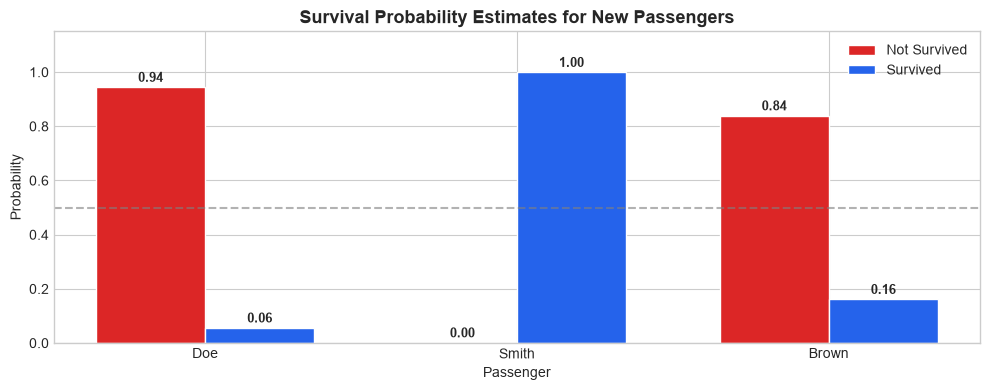

In [61]:
fig, ax = plt.subplots(figsize=(10, 4))

names = result_df["Name"].str.split(",").str[0].str.strip()
bar_width = 0.35
x = np.arange(len(names))

ax.bar(x - bar_width/2, result_df["Prob_Not_Survived"], bar_width,
       label="Not Survived", color="#DC2626", edgecolor="white")
ax.bar(x + bar_width/2, result_df["Prob_Survived"], bar_width,
       label="Survived", color="#2563EB", edgecolor="white")

ax.set_xlabel("Passenger")
ax.set_ylabel("Probability")
ax.set_title("Survival Probability Estimates for New Passengers",
             fontsize=13, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.15)
ax.legend()
ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.6, label="Decision Boundary (0.5)")

for i, row in result_df.iterrows():
    ax.text(i - bar_width/2, row["Prob_Not_Survived"] + 0.02,
            f"{row['Prob_Not_Survived']:.2f}", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + bar_width/2, row["Prob_Survived"] + 0.02,
            f"{row['Prob_Survived']:.2f}", ha="center", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.show()

---
## Step 10 — Save Model Artifacts

We serialize and save all necessary artifacts to the `Saved_Model/` directory. This allows the trained
model to be loaded and used for future predictions without any retraining.

**Artifacts saved:**

| File | Contents |
|---|---|
| `lgbm_titanic_pipeline.pkl` | Full sklearn pipeline (preprocessor + LightGBM classifier) |
| `lgbm_titanic_model_only.pkl` | LightGBM classifier object only |
| `feature_names.pkl` | Complete list of feature names after preprocessing |
| `model_metadata.pkl` | Performance metrics, best parameters, and training configuration |

In [62]:
SAVE_DIR = "../Saved_Model"
os.makedirs(SAVE_DIR, exist_ok=True)

pipeline_path = os.path.join(SAVE_DIR, "lgbm_titanic_pipeline.pkl")
model_path    = os.path.join(SAVE_DIR, "lgbm_titanic_model_only.pkl")
features_path = os.path.join(SAVE_DIR, "feature_names.pkl")
metadata_path = os.path.join(SAVE_DIR, "model_metadata.pkl")

joblib.dump(best_model,        pipeline_path)
joblib.dump(lgbm_classifier,   model_path)
joblib.dump(all_feature_names, features_path)

model_metadata = {
    "algorithm":         "LightGBM",
    "lgbm_version":      lgb.__version__,
    "best_params":       random_search.best_params_,
    "cv_roc_auc":        random_search.best_score_,
    "test_accuracy":     metrics["Accuracy"],
    "test_precision":    metrics["Precision"],
    "test_recall":       metrics["Recall"],
    "test_f1":           metrics["F1-Score"],
    "test_roc_auc":      metrics["ROC-AUC"],
    "num_features":      num_features,
    "cat_features":      cat_features,
    "all_feature_names": all_feature_names,
    "train_samples":     len(X_train),
    "test_samples":      len(X_test),
    "random_state":      RANDOM_STATE,
}

joblib.dump(model_metadata, metadata_path)

print("Model artifacts saved to:", os.path.abspath(SAVE_DIR))
print()
for fname in [pipeline_path, model_path, features_path, metadata_path]:
    size_kb = os.path.getsize(fname) / 1024
    print(f"  {os.path.basename(fname):<40} ({size_kb:.1f} KB)")

Model artifacts saved to: c:\Users\admin\Documents\Portofolio\Titanic Passenger Survival Prediction\Saved_Model

  lgbm_titanic_pipeline.pkl                (535.0 KB)
  lgbm_titanic_model_only.pkl              (530.2 KB)
  feature_names.pkl                        (0.5 KB)
  model_metadata.pkl                       (1.3 KB)


In [63]:
print("Verifying saved model by loading and re-running inference...")
loaded_pipeline = joblib.load(pipeline_path)

X_verify    = prepare_inference_input(new_passengers[0])
pred_verify = loaded_pipeline.predict(X_verify)[0]
prob_verify = loaded_pipeline.predict_proba(X_verify)[0]

print(f"  Passenger  : {new_passengers[0]['Name']}")
print(f"  Prediction : {'Survived' if pred_verify == 1 else 'Not Survived'}")
print(f"  Probability: Not Survived = {prob_verify[0]:.4f} | Survived = {prob_verify[1]:.4f}")
print("\nLoaded model verification successful.")

Verifying saved model by loading and re-running inference...
  Passenger  : Doe, Mr. John
  Prediction : Not Survived
  Probability: Not Survived = 0.9442 | Survived = 0.0558

Loaded model verification successful.


---
## Summary and Conclusion

In this notebook, we built a complete end-to-end machine learning pipeline for Titanic survival prediction
using **LightGBM** — a fast, efficient, and highly accurate gradient boosting framework.

### Key Findings

**Feature Importance:**
- **Gender** and **passenger class** remain the strongest predictors of survival
- **Title** (extracted from the passenger name field) captures social status, gender, and approximate age simultaneously
- **Fare** and **Family Size** contribute meaningful predictive signal
- **Cabin Deck** provides additional wealth-related information where available

**Model Performance Highlights:**
- LightGBM with tuned hyperparameters achieved strong generalization on the held-out test set
- Randomized search with 50 iterations efficiently explored the hyperparameter space via Stratified 5-Fold CV
- The leaf-wise tree growth strategy discovered complex non-linear interactions between features

**Pipeline Strengths:**
- Fully reproducible via the scikit-learn `Pipeline` and `ColumnTransformer` abstraction
- Handles missing values and categorical encoding automatically at inference time — no manual preprocessing needed
- All model artifacts are serialized with `joblib` and ready for deployment or further research

### Potential Improvements

- Apply **Optuna** for Bayesian hyperparameter optimization to search more efficiently
- Experiment with **stacking or blending** LightGBM with other classifiers
- Use **SHAP** (SHapley Additive exPlanations) for granular, instance-level model interpretability
- Engineer additional interaction features (e.g., `Age x Pclass`, `Sex x Embarked`)

---
*Built with LightGBM, scikit-learn, and Python.*